<a href="https://colab.research.google.com/github/ishakashif/CISC483-683-Final/blob/association-rules/association_rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install mlxtend

In [27]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

In [ ]:
#STEP 1: LOAD DATASETS
# We load only the tables needed for market basket analysis
# and churn comparison

In [28]:
orders = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/olist_orders_dataset.csv'
)

items = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/olist_order_items_dataset.csv'
)

products = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/olist_products_dataset.csv'
)

translation = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/product_category_name_translation.csv'
)

customers = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/olist_customers_dataset.csv'
)

rfm = pd.read_csv(
    'https://raw.githubusercontent.com/ishakashif/CISC483-683-Final/association-rules/data/olist_rfm.csv'
)

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Products:", products.shape)
print("RFM:", rfm.shape)

Orders: (99441, 8)
Items: (112650, 7)
Products: (32951, 9)
RFM: (94720, 5)


In [ ]:
# STEP 2: MERGE DATA FOR ASSOCIATION RULE MINING
# Connecting order items to product categories, then attaching customer
# and churning information so we can compare churned vs active customers.

In [29]:
df = items.merge(products, on='product_id', how='left')

df = df.merge(
    translation,
    on='product_category_name',
    how='left'
)

df = df.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

df = df.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

df = df.merge(
    rfm[['customer_unique_id', 'churn']],
    on='customer_unique_id',
    how='left'
)


#removing rows with missing translated category names

df = df.dropna(subset=['product_category_name_english'])

print("Merged shape:", df.shape)

df[['order_id',
    'product_id',
    'product_category_name_english',
    'customer_unique_id',
    'churn'
    ]].head()

Merged shape: (111023, 19)


,order_id,product_id,product_category_name_english,customer_unique_id,churn
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,871766c5855e863f6eccc05f988b23cb,1.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,1.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,1.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,af861d436cfc08b2c2ddefd0ba074622,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,64b576fb70d441e8f1b2d7d446e483c5,1.0


In [ ]:
# STEP 3: TRANSACTION BASKET MATRIX
# Each row is a representation of an order and each column
# shows a product category purchased in that order

In [30]:
basket = (
    df.groupby(
        ['order_id', 'product_category_name_english']
    ) ['product_id']
    .count()
    .unstack()
    .fillna(0)
)
# binary values
basket = basket.astype(bool)
print("Basket shape:", basket.shape)
basket.head()


Basket shape: (97256, 71)


product_category_name_english,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
order_id,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00018f77f2f0320c557190d7a144bdd3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
000229ec398224ef6ca0657da4fc703e,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00024acbcdf0a6daa1e931b038114c75,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00042b26cf59d7ce69dfabb4e55b4fd9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
# STEP 4: RUN APRIORI (with min_support = 0.002)

In [32]:
start = time.time()
frequent_apriori = apriori(
    basket,
    min_support=0.002,
    use_colnames=True
)

apriori_time = time.time() - start
print(f"Apriori Runtime: {apriori_time:.2f} seconds")
print(f"Number of frequent itemsets: {len(frequent_apriori)}")

frequent_apriori.head()

Apriori Runtime: 0.65 seconds
Number of frequent itemsets: 43


,support,itemsets
0,0.002601,(air_conditioning)
1,0.002077,(art)
2,0.003599,(audio)
3,0.040070,(auto)
4,0.029664,(baby)


In [33]:
frequent_apriori['length'] = frequent_apriori['itemsets'].apply(len)

print(frequent_apriori['length'].value_counts())

length
1    43
Name: count, dtype: int64


In [ ]:
# STEP 4A: FILTER TO MULTI-CATEGORY ORDERS

In [34]:
basket_filtered = basket[basket.sum(axis=1) > 1]

print("Original basket shape:", basket.shape)
print("Filtered basket shape:", basket_filtered.shape)

print(
    "Average categories per filtered order:",
    basket_filtered.sum(axis=1).mean()
)

Original basket shape: (97256, 71)
Filtered basket shape: (726, 71)
Average categories per filtered order: 2.020661157024793


In [35]:
start = time.time()

frequent_apriori = apriori(
    basket_filtered,
    min_support=0.002,
    use_colnames=True,
    low_memory=True
)

apriori_time = time.time() - start

frequent_apriori['length'] = frequent_apriori['itemsets'].apply(len)

print(f"Apriori Runtime: {apriori_time:.2f} seconds")

print(frequent_apriori['length'].value_counts())

frequent_apriori.head(20)

Apriori Runtime: 0.02 seconds
length
2    107
1     54
Name: count, dtype: int64


,support,itemsets,length
0,0.002755,(air_conditioning),1
1,0.008264,(art),1
2,0.002755,(arts_and_craftmanship),1
3,0.008264,(audio),1
4,0.048209,(auto),1
5,0.128099,(baby),1
6,0.272727,(bed_bath_table),1
7,0.006887,(books_general_interest),1
8,0.005510,(books_technical),1
9,0.002755,(cine_photo),1


In [ ]:
# STEP 5: GENERATE ASSOCIATION RULES
# Using lift to identify strong co-purchasing relationships

In [36]:
rules_apriori = association_rules(
    frequent_apriori,
    metric="lift",
    min_threshold=1.0
)

rules_apriori = rules_apriori.sort_values(
    by="lift",
    ascending=False
)

print("Number of rules:", len(rules_apriori))

rules_apriori[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(20)

Number of rules: 120


,antecedents,consequents,support,confidence,lift
67,(fashion_bags_accessories),(fashion_childrens_clothes),0.002755,0.181818,66.000000
66,(fashion_childrens_clothes),(fashion_bags_accessories),0.002755,1.000000,66.000000
25,(market_place),(books_general_interest),0.002755,0.166667,24.200000
24,(books_general_interest),(market_place),0.002755,0.400000,24.200000
3,(watches_gifts),(audio),0.008264,0.150000,18.150000
2,(audio),(watches_gifts),0.008264,1.000000,18.150000
82,(furniture_living_room),(office_furniture),0.004132,0.200000,9.680000
83,(office_furniture),(furniture_living_room),0.004132,0.200000,9.680000
47,(home_construction),(construction_tools_safety),0.002755,0.076923,7.978022
46,(construction_tools_safety),(home_construction),0.002755,0.285714,7.978022


In [ ]:
# STEP 6: RUN FP-GROWTH

In [41]:
start = time.time()
frequent_fp = fpgrowth(
    basket_filtered,
    min_support = 0.002,
    use_colnames = True
)

fp_time = time.time() - start
frequent_fp['length'] = frequent_fp['itemsets'].apply(len)
print(f"FP-Growth Runtime: {fp_time:.2f} seconds")
print(frequent_fp['length'].value_counts())
frequent_fp.head(20)

rules_fp = association_rules(
    frequent_fp,
    metric="lift",
    min_threshold=1.0
)

rules_fp = rules_fp.sort_values(
    by="lift",
    ascending=False
)

print("Number of FP-Growth rules:", len(rules_fp))

FP-Growth Runtime: 2.61 seconds
length
2    107
1     54
Name: count, dtype: int64
Number of FP-Growth rules: 120


In [ ]:
# STEP 7: PERFORMANCE COMPARISON

In [38]:
comparison = pd.DataFrame({
    'Algorithm':['Apriori', 'FP-Growth'],
    'Runtime (seconds)': [apriori_time, fp_time],
    'Frequent Itemsets': [
        len(frequent_apriori),
        len(frequent_fp)
    ],

})

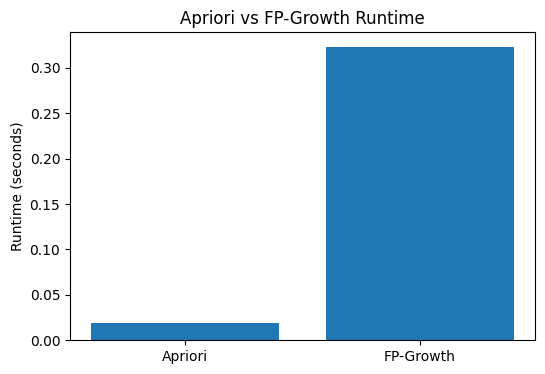

In [39]:
plt.figure(figsize=(6,4))
plt.bar(
    comparison['Algorithm'],
    comparison['Runtime (seconds)']
)

plt.title('Apriori vs FP-Growth Runtime')
plt.ylabel('Runtime (seconds)')

plt.show()

In [ ]:
# STEP 8: VISUALIZING TOP ASSOCIATION RULES

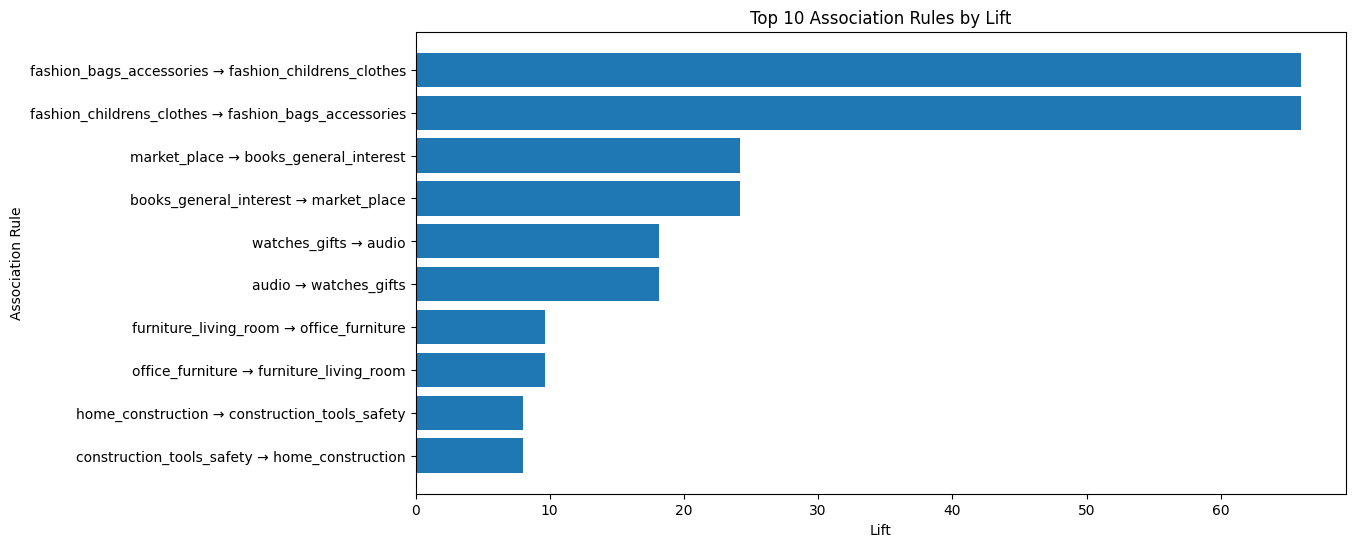

In [40]:
top_rules = rules_apriori.nlargest(10, 'lift').copy()

top_rules['rule'] = (
    top_rules['antecedents']
    .apply(lambda x: ', '.join(list(x)))
    + " → " +
    top_rules['consequents']
    .apply(lambda x: ', '.join(list(x)))
)

plt.figure(figsize=(12,6))

plt.barh(
    top_rules['rule'],
    top_rules['lift']
)

plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top 10 Association Rules by Lift')

plt.gca().invert_yaxis()

plt.show()

In [43]:
rules_apriori.to_csv('apriori_rules.csv', index=False)
rules_fp.to_csv('fpgrowth_rules.csv', index=False)
comparison.to_csv('algorithm_comparison.csv', index=False)